# Notebook 1 - 01_part1_linreg_1feature.ipynb
**Escuela Colombiana de Ingeniería Julio Garavito**  
**Student:** Santiago Botero García  

## 1. Introduction and Objective

In this notebook, we study a simplified stellar luminosity modeling problem using linear regression with a single feature.

The goal is to model stellar luminosity $L$ as a function of stellar mass $M$ using a linear hypothesis of the form:

$$
\hat{L} = wM + b
$$

This exercise focuses on implementing all components of linear regression from first principles, including the hypothesis function, the loss function, gradient computation, and gradient descent optimization, without relying on high-level machine learning libraries.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from abc import ABC, abstractmethod


class Regression(ABC):
    @abstractmethod
    def predict(x, w, b):
        pass

class LinearRegression(Regression):
    @staticmethod
    def predict(x, w, b):
        return w * x + b

class PolynomialRegression(Regression):
    @staticmethod
    def predict(x, w, b):
        return x @ w + b

class CostFunction:
    @staticmethod
    def compute_cost(x, y, w, b):
        x = np.asarray(x)
        y = np.asarray(y)

        m = x.shape[0]
        y_hat = w * x + b
        errors = y_hat - y

        return (1 / (2 * m)) * np.sum(errors ** 2)

    @staticmethod
    def compute_cost_multi(X, y, w, b):
        m = X.shape[0]
        y_hat = X @ w + b
        errors = y_hat - y
        return (1 / (2 * m)) * np.sum(errors ** 2)

    @staticmethod
    def visualize_as_surface(x, y):
        w_values = np.linspace(-1.0, 7.0, 60)
        b_values = np.linspace(-5.0, 10.0, 60)

        W, B, J = [], [], []

        for b in b_values:
            row_w, row_b, row_j = [], [], []
            for w in w_values:
                row_w.append(w)
                row_b.append(b)
                row_j.append(CostFunction.compute_cost(x, y, w, b))
            W.append(row_w)
            B.append(row_b)
            J.append(row_j)

        W, B, J = map(np.array, (W, B, J))

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection="3d")
        ax.plot_surface(W, B, J, cmap=cm.viridis, linewidth=0)
        ax.set_xlabel("w")
        ax.set_ylabel("b")
        ax.set_zlabel("J(w,b)")
        ax.set_title("Cost Surface")
        plt.show()

class Gradient:
    @staticmethod
    def gradient_descent(x, y, w_init, b_init, alpha, num_iters):
        x = np.asarray(x)
        y = np.asarray(y)

        w, b = w_init, b_init
        history = []

        for i in range(num_iters):
            dj_dw, dj_db = Gradient.compute_gradients(x, y, w, b)

            w -= alpha * dj_dw
            b -= alpha * dj_db

            cost = CostFunction.compute_cost(x, y, w, b)
            history.append((i, cost))

            if i % max(1, num_iters // 10) == 0:
                print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")

        return w, b, history

    @staticmethod
    def gradient_descent_multi(X, y, w_init, b_init, alpha, num_iters):
        X = np.asarray(X)
        y = np.asarray(y)

        w = w_init.copy()
        b = b_init

        it_hist, cost_hist = [], []
        m = X.shape[0]

        for i in range(num_iters):
            y_hat = X @ w + b
            errors = y_hat - y

            dj_dw = (1 / m) * (X.T @ errors)
            dj_db = (1 / m) * np.sum(errors)

            w -= alpha * dj_dw
            b -= alpha * dj_db

            cost = CostFunction.compute_cost_multi(X, y, w, b)
            it_hist.append(i)
            cost_hist.append(cost)

            if i % max(1, num_iters // 10) == 0:
                print(f"Iter {i:4d}: cost={cost:8.4f}")

        return w, b, it_hist, cost_hist

    @staticmethod
    def compute_gradients(x, y, w, b):
        m = x.shape[0]
        y_hat = w * x + b
        errors = y_hat - y

        dj_dw = (1 / m) * np.sum(errors * x)
        dj_db = (1 / m) * np.sum(errors)
        return dj_dw, dj_db

    @staticmethod
    def feature_scale(x):
        x = np.asarray(x)

        means = x.mean(axis=0)
        stds = x.std(axis=0, ddof=0)
        stds[stds == 0] = 1.0

        x_scaled = (x - means) / stds
        return x_scaled, means, stds

    @staticmethod
    def plot_cost(it_hist, cost_hist):
        plt.figure()
        plt.plot(it_hist[10:], cost_hist[10:])
        plt.xlabel("Iteration")
        plt.ylabel("Cost J(w,b)")
        plt.title("Cost vs Iterations")
        plt.show()

    @staticmethod
    def visualize_fitted_line(x, y, w, b):
        y_pred = LinearRegression.predict(x, w, b)

        plt.figure()
        plt.scatter(x, y, label="Data")
        plt.plot(x, y_pred, color="red", label="Fitted line")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.title("Linear Regression Fit")
        plt.legend()
        plt.show()


## 2. Dataset Description

The dataset represents main-sequence-like stars, where luminosity increases rapidly with stellar mass.

* (M): stellar mass in units of solar mass $(M_\odot)$
* (L): stellar luminosity in units of solar luminosity $(L_\odot)$

The dataset is small and intentionally simple to allow full inspection of the learning process.

In [2]:
M = np.array([0.6,0.8,1.0,1.2,1.4,1.6,1.8,2.0,2.2,2.4])
L = np.array([0.15,0.35,1.00,2.30,4.10,7.00,11.2,17.5,25.0,35.0])

## 3. Dataset Visualization

We begin by visualizing the relationship between stellar mass and luminosity.

This plot allows us to assess whether a linear model is a reasonable first approximation and to identify potential nonlinear trends or systematic deviations.

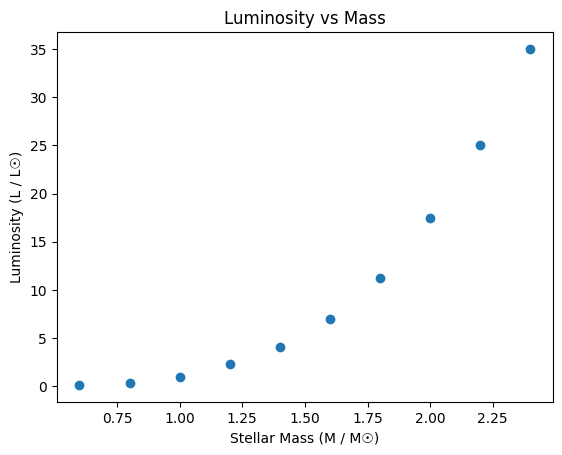

In [3]:
plt.figure()
plt.scatter(M, L)
plt.xlabel("Stellar Mass (M / M☉)")
plt.ylabel("Luminosity (L / L☉)")
plt.title("Luminosity vs Mass")
plt.show()

**Discussion:**

* Trend is monotonic but **clearly nonlinear**
* Linear regression will approximate average growth
* Physical stellar models predict $(L \propto M^3)–(M^4)$

## 4. Model Hypothesis and Loss Function

We define a linear hypothesis function with an explicit bias term.

To quantify model performance, we use the Mean Squared Error (MSE) loss function:

$$
J(w,b) = \frac{1}{N}\sum_{i=1}^{N}(\hat{L}_i - L_i)^2
$$

This loss measures the average squared difference between predicted and observed luminosities.

## 5. Cost Surface Visualization

To better understand the optimization landscape, we evaluate the loss function over a grid of values for (w) and (b).

Visualizing the cost surface helps illustrate how gradient descent navigates the parameter space and where the global minimum is located.

The minimum of this surface corresponds to the optimal model parameters.

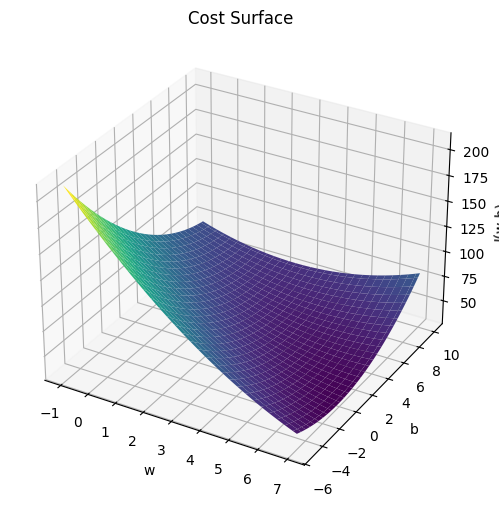

In [4]:
CostFunction.visualize_as_surface(M, L)

## 6. Gradient Derivation

To apply gradient descent, we compute the partial derivatives of the loss function with respect to (w) and (b).

These gradients indicate how the parameters should be updated in order to reduce the loss at each iteration.

## 7. Gradient Descent (Non-vectorized)

In this section, gradient descent is implemented using explicit loops over the dataset.

This approach closely follows the mathematical definition and provides transparency into how gradients are accumulated from individual samples.

In [5]:
w_init = 0.0
b_init = 0.0

w, b, history = Gradient.gradient_descent(
    M, L, w_init, b_init, alpha=0.05, num_iters=2000
)

Iteration    0: w= 1.0761, b= 0.5180, cost= 91.6326
Iteration  200: w=13.3959, b=-8.9910, cost= 13.7695
Iteration  400: w=16.2976, b=-13.7989, cost= 10.3907
Iteration  600: w=17.4209, b=-15.6600, cost=  9.8844
Iteration  800: w=17.8557, b=-16.3804, cost=  9.8085
Iteration 1000: w=18.0240, b=-16.6593, cost=  9.7972
Iteration 1200: w=18.0892, b=-16.7673, cost=  9.7954
Iteration 1400: w=18.1144, b=-16.8091, cost=  9.7952
Iteration 1600: w=18.1241, b=-16.8252, cost=  9.7952
Iteration 1800: w=18.1279, b=-16.8315, cost=  9.7951


## 8. Gradient Descent (Vectorized)

We now reimplement gradient descent using NumPy vectorization.

Vectorized operations are more efficient and scalable, and they reflect best practices in numerical computing and machine learning implementations.

In [6]:
dj_dw, dj_db = Gradient.compute_gradients(M, L, w, b)

## 9. Convergence Analysis

We analyze the convergence behavior of gradient descent by plotting the loss as a function of training iterations.

This plot provides insight into the stability and speed of convergence and helps detect issues such as divergence or slow learning.

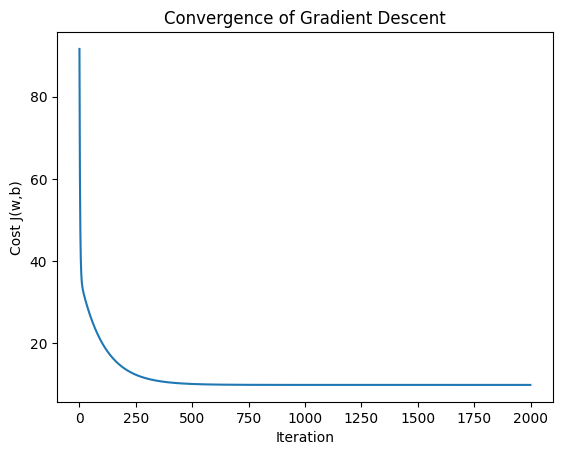

In [7]:
iters, costs = zip(*history)

plt.figure()
plt.plot(iters, costs)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Convergence of Gradient Descent")
plt.show()

## 10. Learning Rate Experiments

To study the impact of the learning rate, we train the model using multiple values of the learning rate.

For each experiment, we report the final learned parameters and the final loss.

In [8]:
alphas = [0.01, 0.05, 0.1]

for a in alphas:
    w, b, hist = Gradient.gradient_descent(M, L, 0.0, 0.0, a, 2000)
    print(f"alpha={a}: w={w:.4f}, b={b:.4f}, final cost={hist[-1][1]:.4f}")

Iteration    0: w= 0.2152, b= 0.1036, cost=112.0896
Iteration  200: w= 7.9674, b=-0.0073, cost= 28.0913
Iteration  400: w= 9.7253, b=-2.9093, cost= 22.3208
Iteration  600: w=11.1759, b=-5.3129, cost= 18.3703
Iteration  800: w=12.3762, b=-7.3015, cost= 15.6658
Iteration 1000: w=13.3693, b=-8.9470, cost= 13.8142
Iteration 1200: w=14.1910, b=-10.3085, cost= 12.5466
Iteration 1400: w=14.8709, b=-11.4350, cost= 11.6788
Iteration 1600: w=15.4334, b=-12.3670, cost= 11.0847
Iteration 1800: w=15.8989, b=-13.1383, cost= 10.6780
alpha=0.01: w=16.2822, b=-13.7735, final cost=10.4007
Iteration    0: w= 1.0761, b= 0.5180, cost= 91.6326
Iteration  200: w=13.3959, b=-8.9910, cost= 13.7695
Iteration  400: w=16.2976, b=-13.7989, cost= 10.3907
Iteration  600: w=17.4209, b=-15.6600, cost=  9.8844
Iteration  800: w=17.8557, b=-16.3804, cost=  9.8085
Iteration 1000: w=18.0240, b=-16.6593, cost=  9.7972
Iteration 1200: w=18.0892, b=-16.7673, cost=  9.7954
Iteration 1400: w=18.1144, b=-16.8091, cost=  9.7952


## 11. Final Model Fit

The final regression line is plotted together with the original data.

This visualization allows us to identify systematic errors and assess how well a linear model captures the underlying physical relationship.

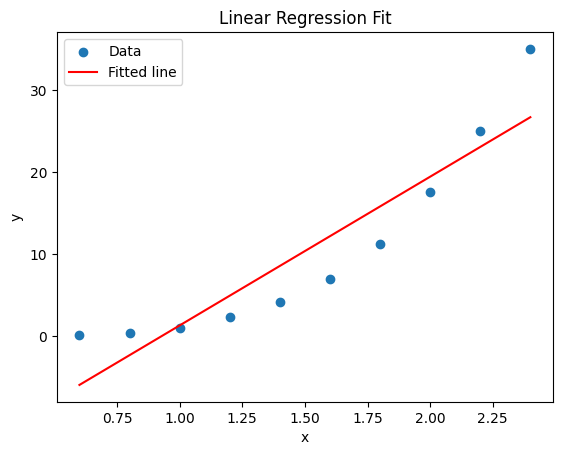

In [9]:
Gradient.visualize_fitted_line(M, L, w, b)

## 12. Conceptual Discussion

**Astrophysical meaning of $w$:**  
The parameter $w$ represents the sensitivity of luminosity to changes in stellar mass. Physically, it approximates how rapidly luminosity increases as mass increases within the explored range.

**Limitations of a linear model:**  
Stellar luminosity is known to follow a highly nonlinear relationship with mass. A linear model cannot capture this behavior accurately, especially at higher masses, motivating the use of polynomial and interaction terms.